In [1]:
!git clone https://github.com/CristylePGarrard/Fiverr-consulting-toolkit.git
%cd Fiverr-consulting-toolkit


Cloning into 'Fiverr-consulting-toolkit'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 27 (delta 4), reused 17 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 31.87 KiB | 6.37 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/Fiverr-consulting-toolkit


In [2]:
import pandas as pd
import os

def load_fiverr_data(base_path="data/raw"):
    """Loads all Fiverr raw CSV files into a dictionary of DataFrames."""
    files = {
        'about_me': 'FiverrResearch - AboutMe.csv',
        'about_the_gig': 'FiverrResearch - AboutTheGig.csv',
        'gig_title': 'FiverrResearch - GigTitle.csv',
        'manual_data': 'FiverrResearch - ManualData.csv'
    }

    dfs = {}
    for key, filename in files.items():
        file_path = os.path.join(base_path, filename)
        if os.path.exists(file_path):
            dfs[key] = pd.read_csv(file_path)
            print(True, f"Loaded {key}: {dfs[key].shape[0]} rows, {dfs[key].shape[1]} columns")
        else:
            print(False, f"Could not find: {file_path}")

    return dfs

# Execute the function to load the data in your notebook
data = load_fiverr_data()


True Loaded about_me: 74 rows, 2 columns
True Loaded about_the_gig: 61 rows, 2 columns
True Loaded gig_title: 81 rows, 2 columns
True Loaded manual_data: 83 rows, 12 columns


In [3]:
# Inspect columns and data types for each loaded file
for name, df in data.items():
    print(f"\n--- {name.upper()} COLUMNS ---")
    print(df.dtypes)
    print(f"Missing values per column:\n{df.isnull().sum()}")



--- ABOUT_ME COLUMNS ---
about_me_id     int64
about_me       object
dtype: object
Missing values per column:
about_me_id     0
about_me       43
dtype: int64

--- ABOUT_THE_GIG COLUMNS ---
about_gig_id     int64
about_gig       object
dtype: object
Missing values per column:
about_gig_id     0
about_gig       30
dtype: int64

--- GIG_TITLE COLUMNS ---
gig_title_id     int64
gig_title       object
dtype: object
Missing values per column:
gig_title_id     0
gig_title       50
dtype: int64

--- MANUAL_DATA COLUMNS ---
Gig Title                     int64
About the Gig                 int64
About Me                      int64
Reviews                       int64
Stars                       float64
Caption                      object
Description                  object
Package                      object
Cost                          int64
Delivery Timeline (days)      int64
Revisions                    object
Included                     object
dtype: object
Missing values per column:
Gig 

In [6]:
def merge_and_clean_fiverr_data(dfs):
    """Merges the relational Fiverr dataframes and handles missing values."""
    # 1. Start with the main manual data table
    main_df = dfs['manual_data'].copy()

    # 2. Merge Dimension Tables sequentially using the relational IDs
    merged_df = main_df.merge(
        dfs['gig_title'], left_on='Gig Title', right_on='gig_title_id', how='left'
    ).merge(
        dfs['about_the_gig'], left_on='About the Gig', right_on='about_gig_id', how='left'
    ).merge(
        dfs['about_me'], left_on='About Me', right_on='about_me_id', how='left'
    )

    # Drop the redundant ID columns generated by the merge
    columns_to_drop = ['gig_title_id', 'about_gig_id', 'about_me_id']
    merged_df = merged_df.drop(columns=columns_to_drop)

    # 3. Handle Missing Values (Imputation)
    merged_df['about_me'] = merged_df['about_me'].fillna('No bio provided')
    merged_df['about_gig'] = merged_df['about_gig'].fillna('No gig description provided')
    merged_df['gig_title'] = merged_df['gig_title'].fillna('No title provided')
    merged_df['Revisions'] = merged_df['Revisions'].fillna('0')
    merged_df['Included'] = merged_df['Included'].fillna('None specified')

    # 4. Standardize Text Formats (lowercase headers, removing spaces/parentheses)
    merged_df.columns = merged_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

    print(f"✅ Success! Master Dataset Created. Shape: {merged_df.shape}")
    return merged_df

# Execute the function using the 'data' dictionary we loaded earlier
master_df = merge_and_clean_fiverr_data(data)

# Preview a quick slice to confirm it works
master_df[['gig_title', 'cost', 'stars', 'reviews']].head()


✅ Success! Master Dataset Created. Shape: (83, 15)


,gig_title,gig_title,cost,stars,reviews
0,0,I will develop python applications or scripts ...,50,4.9,38
1,0,I will develop python applications or scripts ...,100,4.9,38
2,0,I will develop python applications or scripts ...,200,4.9,38
3,1,I will develop advanced python automation scri...,30,5.0,8
4,1,I will develop advanced python automation scri...,90,5.0,8


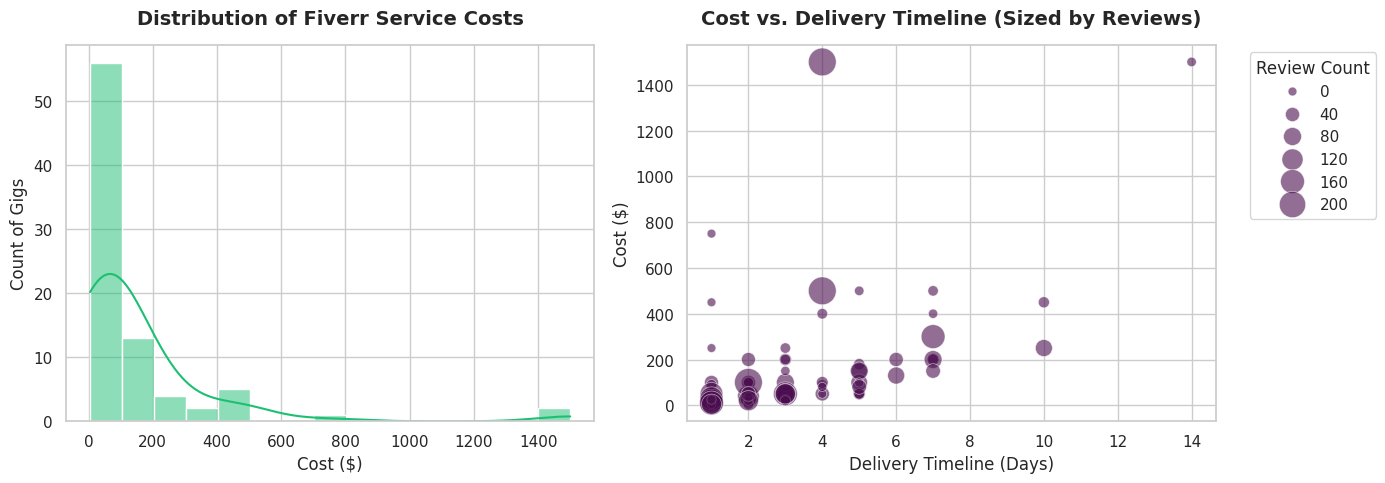

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual style
sns.set_theme(style="whitegrid")

# FIX: Set the figure size correctly to 14 inches wide by 5 inches tall
plt.rcParams['figure.figsize'] = (14, 5)

# Create a figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2)

# --- CHART 1: Pricing Distribution ---
sns.histplot(data=master_df, x='cost', kde=True, color='#1dbf73', ax=ax1, bins=15) # Fiverr Green!
ax1.set_title('Distribution of Fiverr Service Costs', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Cost ($)', fontsize=12)
ax1.set_ylabel('Count of Gigs', fontsize=12)

# --- CHART 2: Price vs. Delivery Timeline ---
sns.scatterplot(data=master_df, x='delivery_timeline_days', y='cost',
                size='reviews', sizes=(40, 400), alpha=0.6, color='#4a0e4e', ax=ax2)
ax2.set_title('Cost vs. Delivery Timeline (Sized by Reviews)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Delivery Timeline (Days)', fontsize=12)
ax2.set_ylabel('Cost ($)', fontsize=12)
ax2.legend(title='Review Count', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


In [9]:
# Save clean data back to the workspace
master_df.to_csv('data/processed/cleaned_fiverr_dataset.csv', index=False)
print("Data pipeline complete! Saved to data/processed/cleaned_fiverr_dataset.csv")


Data pipeline complete! Saved to data/processed/cleaned_fiverr_dataset.csv
